# 02. 첫 번째 신경망 - MNIST 숫자 분류

**모듈**: M2 - 딥러닝 기초
**날짜**: 2026-03-09

CNN(합성곱 신경망)으로 손글씨 숫자를 분류합니다.

```
이미지 (28x28) → Conv → Pool → Conv → Pool → FC → 숫자 (0~9)
```

**왜 MNIST?**
- 딥러닝의 "Hello World"
- 카메라 센서 이미지 처리와 같은 구조 (이미지 → CNN → 특징)
- 나중에 카메라 Encoder가 이 CNN 구조를 확장한 것

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# macOS 한글 폰트
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

# 장치 설정
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'장치: {device}')

PyTorch: 2.10.0
장치: mps


## 1. MNIST 데이터셋 로드

MNIST: 28x28 흑백 손글씨 숫자 이미지 70,000장
- 훈련: 60,000장
- 테스트: 10,000장

In [2]:
# 데이터 전처리: 이미지를 텐서로 변환 + 정규화
transform = transforms.Compose([
    transforms.ToTensor(),           # (28,28) → (1,28,28), 0~1 정규화
    transforms.Normalize((0.5,), (0.5,))  # -1~1로 변환
])

# 데이터 다운로드
train_dataset = datasets.MNIST(root='../../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='../../data', train=False, download=True, transform=transform)

# DataLoader: 미니배치로 묶어서 제공
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f'훈련 데이터: {len(train_dataset):,}장')
print(f'테스트 데이터: {len(test_dataset):,}장')
print(f'이미지 shape: {train_dataset[0][0].shape}')
print(f'클래스: 0~9 (숫자 10개)')

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

훈련 데이터: 60,000장
테스트 데이터: 10,000장
이미지 shape: torch.Size([1, 28, 28])
클래스: 0~9 (숫자 10개)


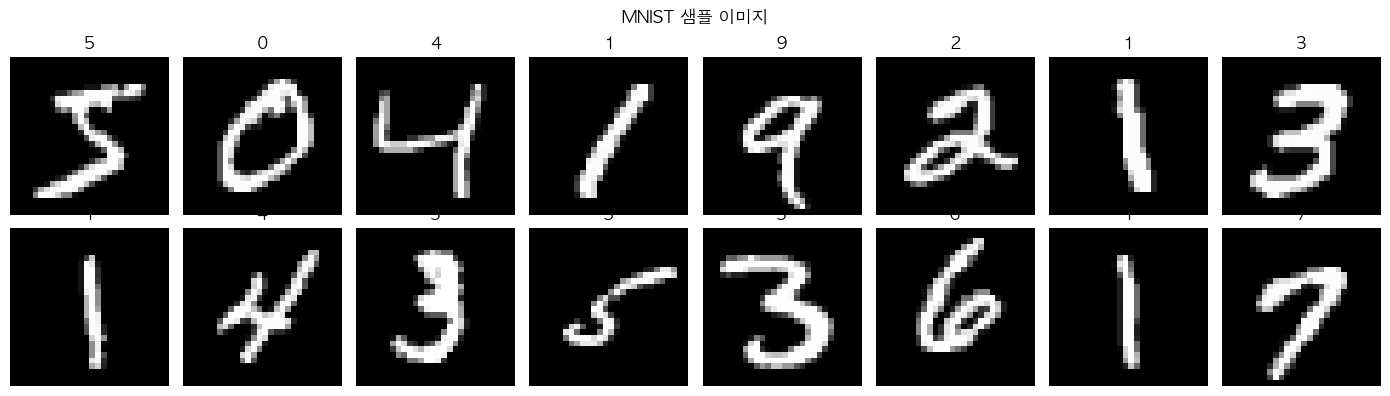

MNIST vs 카메라 센서 비교:
  MNIST:  (1, 28, 28) 흑백, 숫자 분류
  카메라: (3, 64, 64) RGB, 장애물 인식
  → 같은 CNN 구조로 처리 가능!


In [3]:
# 데이터 시각화
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{label}')
    ax.axis('off')

plt.suptitle('MNIST 샘플 이미지', fontweight='bold')
plt.tight_layout()
plt.show()

# 카메라 센서와 비교
print('MNIST vs 카메라 센서 비교:')
print(f'  MNIST:  (1, 28, 28) 흑백, 숫자 분류')
print(f'  카메라: (3, 64, 64) RGB, 장애물 인식')
print(f'  → 같은 CNN 구조로 처리 가능!')

## 2. CNN 모델 정의

CNN이 이미지에서 특징을 추출하는 과정:

```
입력 (1,28,28)
  → Conv1 (32필터, 3x3) → ReLU → MaxPool (14x14)
  → Conv2 (64필터, 3x3) → ReLU → MaxPool (7x7)
  → Flatten → FC1 (128) → ReLU → FC2 (10)
  → 출력: 숫자 0~9 확률
```

- **Conv**: 작은 필터(3x3)로 이미지를 스캔하며 특징(가장자리, 곡선 등) 감지
- **Pool**: 특징 맵 크기를 줄여 핵심만 남김
- **FC**: 추출한 특징으로 최종 분류

In [4]:
class MNISTClassifier(nn.Module):
    """CNN으로 MNIST 숫자 분류"""
    
    def __init__(self):
        super().__init__()
        # 특징 추출 (이 부분이 나중에 카메라 Encoder가 됨)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   # (1,28,28) → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                   # (32,28,28) → (32,14,14)
            nn.Conv2d(32, 64, 3, padding=1),   # (32,14,14) → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2),                   # (64,14,14) → (64,7,7)
        )
        # 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                      # (64,7,7) → (3136,)
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),                # 10개 숫자
        )
    
    def forward(self, x):
        features = self.features(x)
        output = self.classifier(features)
        return output

model = MNISTClassifier().to(device)
print(model)
print(f'\n파라미터 수: {sum(p.numel() for p in model.parameters()):,}개')

# 테스트 입력
test_input = torch.randn(1, 1, 28, 28).to(device)
test_output = model(test_input)
print(f'\n입력: {test_input.shape} → 출력: {test_output.shape}')

MNISTClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

파라미터 수: 421,642개



입력: torch.Size([1, 1, 28, 28]) → 출력: torch.Size([1, 10])


## 3. 학습 루프

반복 과정:
1. **순전파**: 이미지 → 모델 → 예측
2. **손실 계산**: 예측 vs 정답
3. **역전파**: 기울기 계산
4. **가중치 업데이트**: 기울기 방향으로 조정

In [5]:
# 손실함수 + 옵티마이저
criterion = nn.CrossEntropyLoss()  # 분류용 손실함수
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 기록
train_losses = []
test_accuracies = []

def evaluate(model, test_loader):
    """테스트 정확도 계산"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total

# 학습 (5 에포크)
epochs = 5
print(f'학습 시작 ({device})...')
print(f'{"Epoch":>5} | {"Loss":>8} | {"정확도":>8}')
print('-' * 30)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # 순전파
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 역전파 + 업데이트
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = evaluate(model, test_loader)
    
    train_losses.append(avg_loss)
    test_accuracies.append(accuracy)
    
    print(f'{epoch+1:>5} | {avg_loss:>8.4f} | {accuracy:>7.1%}')

print(f'\n최종 정확도: {test_accuracies[-1]:.1%}')

학습 시작 (mps)...
Epoch |     Loss |      정확도
------------------------------


    1 |   0.1577 |   98.4%


    2 |   0.0466 |   99.0%


    3 |   0.0317 |   98.8%


    4 |   0.0232 |   99.0%


    5 |   0.0183 |   99.0%

최종 정확도: 99.0%


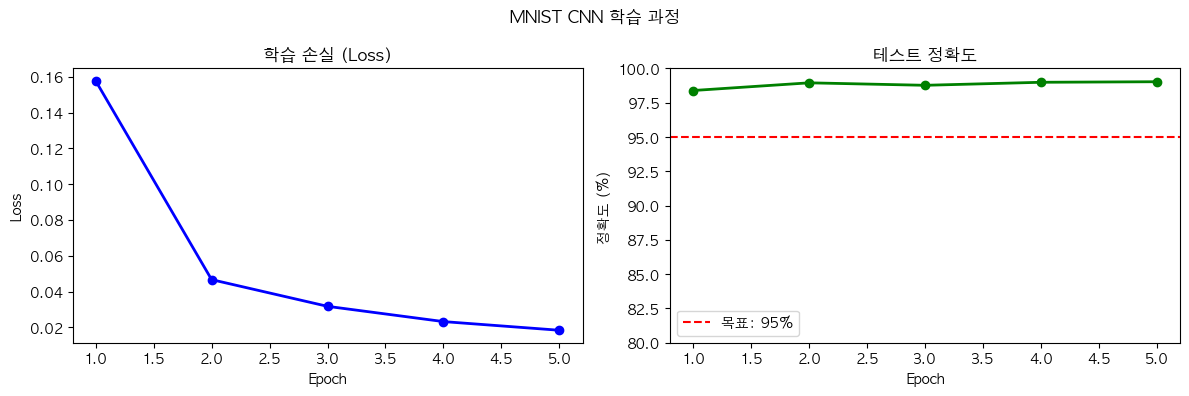

In [6]:
# 학습 과정 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs+1), train_losses, 'b-o', linewidth=2)
ax1.set_title('학습 손실 (Loss)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, epochs+1), [a*100 for a in test_accuracies], 'g-o', linewidth=2)
ax2.axhline(y=95, color='r', linestyle='--', label='목표: 95%')
ax2.set_title('테스트 정확도')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('정확도 (%)')
ax2.set_ylim(80, 100)
ax2.legend()

plt.suptitle('MNIST CNN 학습 과정', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 예측 결과 시각화

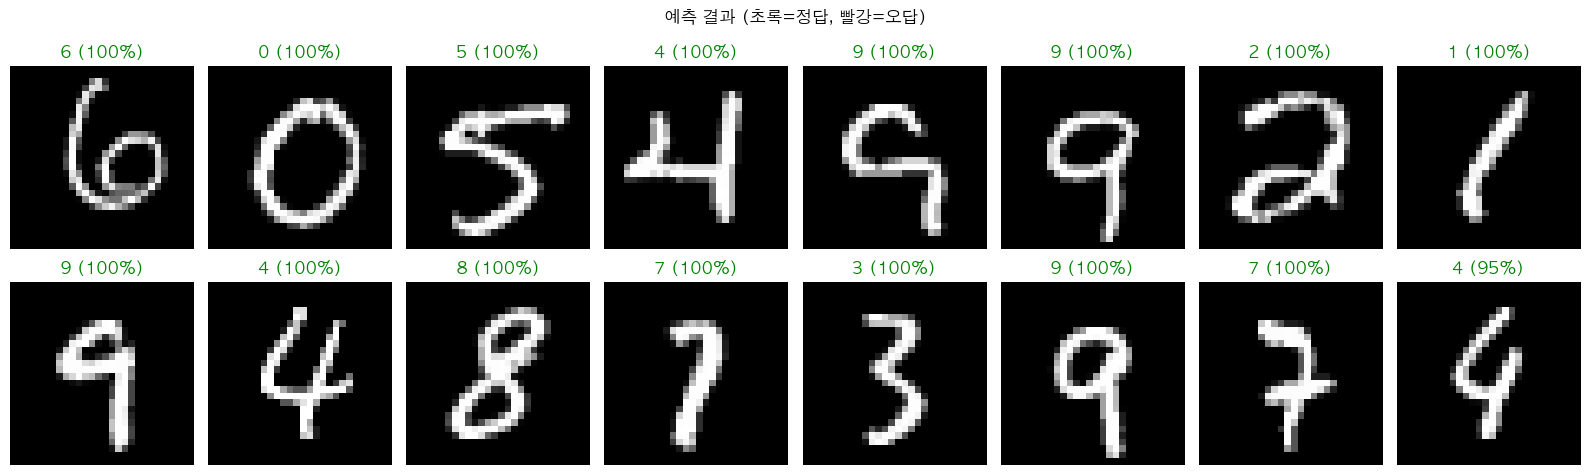

In [7]:
# 테스트 이미지로 예측
model.eval()
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        img, true_label = test_dataset[i + 100]  # 100번째부터
        output = model(img.unsqueeze(0).to(device))
        pred_label = output.argmax(1).item()
        confidence = torch.softmax(output, dim=1).max().item()
        
        ax.imshow(img.squeeze(), cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'{pred_label} ({confidence:.0%})', color=color, fontweight='bold')
        ax.axis('off')

plt.suptitle('예측 결과 (초록=정답, 빨강=오답)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. CNN이 보는 것: 특징 맵 시각화

Conv1 필터가 실제로 어떤 특징을 감지하는지 봅니다.
- 가장자리(edge), 코너, 곡선 등을 감지

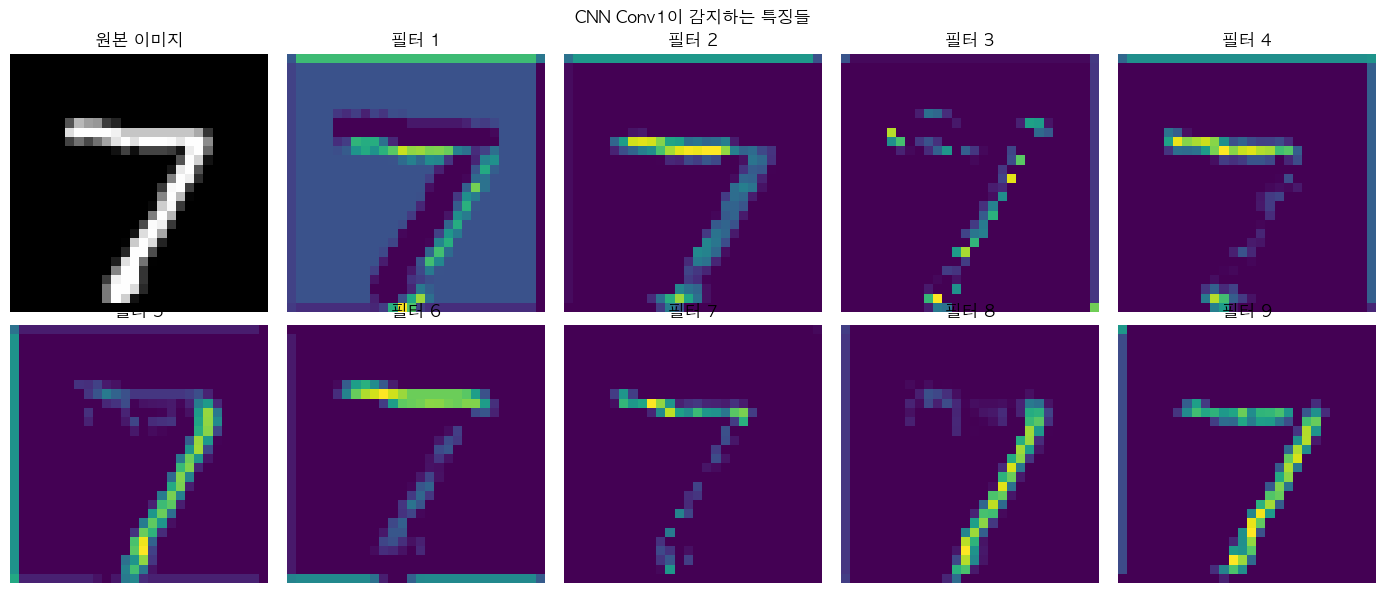

각 필터가 다른 특징(가장자리, 곡선 등)을 감지합니다.
카메라 센서 Encoder도 이런 방식으로 장애물 특징을 추출할 것입니다.


In [8]:
# Conv1 특징 맵 시각화
model.eval()
sample_img = test_dataset[0][0].unsqueeze(0).to(device)

# Conv1 출력 추출
with torch.no_grad():
    conv1_out = model.features[0](sample_img)  # Conv2d
    conv1_relu = model.features[1](conv1_out)   # ReLU

# 원본 + 처음 8개 필터 결과
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# 원본
axes[0, 0].imshow(sample_img.cpu().squeeze(), cmap='gray')
axes[0, 0].set_title('원본 이미지')
axes[0, 0].axis('off')

# 특징 맵
for i in range(9):
    row, col = (i + 1) // 5, (i + 1) % 5
    feature_map = conv1_relu[0, i].cpu().numpy()
    axes[row, col].imshow(feature_map, cmap='viridis')
    axes[row, col].set_title(f'필터 {i+1}')
    axes[row, col].axis('off')

plt.suptitle('CNN Conv1이 감지하는 특징들', fontweight='bold')
plt.tight_layout()
plt.show()

print('각 필터가 다른 특징(가장자리, 곡선 등)을 감지합니다.')
print('카메라 센서 Encoder도 이런 방식으로 장애물 특징을 추출할 것입니다.')

## 6. 파이프라인 연결

이 CNN 구조가 나중에 어떻게 사용되는지:

In [9]:
print('=== MNIST CNN → 카메라 Encoder 확장 ===')
print()
print('지금 (MNIST):')
print('  입력: (1, 28, 28) 흑백 숫자')
print('  Conv → Pool → Conv → Pool → FC')
print('  출력: (10,) 숫자 확률')
print()
print('나중에 (카메라 Encoder, M5):')
print('  입력: (3, 64, 64) RGB 장면')
print('  Conv → Pool → Conv → Pool → FC')
print('  출력: (16,) 잠재 벡터 ← 이것이 Fusion에 입력됨!')
print()
print('핵심 차이:')
print('  - 채널: 1 → 3 (흑백 → RGB)')
print('  - 크기: 28x28 → 64x64')
print('  - 출력: 분류(10) → 잠재벡터(16)')
print('  - 구조는 동일!')
print()
print('실습 2 완료! 다음: 실습 3 (센서 이미지 특징 추출기)')

=== MNIST CNN → 카메라 Encoder 확장 ===

지금 (MNIST):
  입력: (1, 28, 28) 흑백 숫자
  Conv → Pool → Conv → Pool → FC
  출력: (10,) 숫자 확률

나중에 (카메라 Encoder, M5):
  입력: (3, 64, 64) RGB 장면
  Conv → Pool → Conv → Pool → FC
  출력: (16,) 잠재 벡터 ← 이것이 Fusion에 입력됨!

핵심 차이:
  - 채널: 1 → 3 (흑백 → RGB)
  - 크기: 28x28 → 64x64
  - 출력: 분류(10) → 잠재벡터(16)
  - 구조는 동일!

실습 2 완료! 다음: 실습 3 (센서 이미지 특징 추출기)
